In [660]:
import networkx as nx
import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import operator
np.random.seed(1)

ox.__version__

'2.1.0'

### Initial state

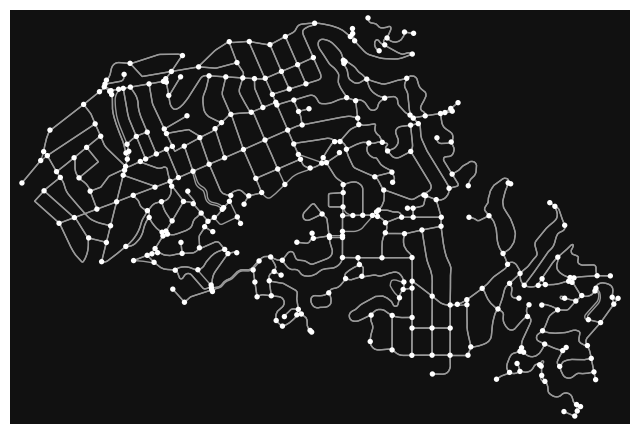

In [661]:
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

OSMnx geocodes the query "Piedmont, California, USA" to retrieve the place boundaries of that city from the Nominatim API, retrieves the drivable street network data within those boundaries from the Overpass API, constructs a graph model, then simplifies/corrects its topology such that nodes represent intersections and dead-ends and edges represent the street segments linking them. All of this is discussed in detail in the documentation and these examples.

OSMnx models all networks as NetworkX `MultiDiGraph` objects. You can convert to:
  - undirected MultiGraphs
  - DiGraphs without (possible) parallel edges
  - GeoPandas node/edge GeoDataFrames

Note that converting to an undirected MultiGraph is really only meant for use cases where a function or algorithm only accepts a MultiGraph argument. If you just want a fully bidirectional graph (such as for a walking network), just configure the `settings` module’s `bidirectional_network_types` before creating your graph.

In [662]:
# get a fully bidirection network (as a MultiDiGraph)
ox.settings.bidirectional_network_types += "drive"
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")

# convert your MultiDiGraph to an undirected MultiGraph
M = ox.convert.to_undirected(G)

# convert your MultiDiGraph to a DiGraph without parallel edges
D = ox.convert.to_digraph(G)

In [663]:
# you can convert your graph to node and edge GeoPandas GeoDataFrames
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
gdf_nodes.head()

,y,x,street_count,highway,junction,geometry
osmid,,,,,,
53017091,37.826250,-122.247604,3,NaN,NaN,POINT (-122.2476 37.82625)
53018397,37.824220,-122.247198,3,stop,NaN,POINT (-122.2472 37.82422)
53018399,37.824900,-122.246113,3,NaN,NaN,POINT (-122.24611 37.8249)
53018402,37.825406,-122.245338,3,NaN,NaN,POINT (-122.24534 37.82541)
53018404,37.825948,-122.244467,3,NaN,NaN,POINT (-122.24447 37.82595)


In [664]:
gdf_edges.head()

osmid      highway          name  oneway reversed  \
u        v        key                                                          
53017091 53064327 0      6345781  residential   Rose Avenue   False    False   
         53075599 0      6345781  residential   Rose Avenue   False     True   
53018397 53018399 0      6327298  residential   Lake Avenue   False    False   
         53018411 0    196739937     tertiary  Linda Avenue   False    False   
         53097980 0    196739937     tertiary  Linda Avenue   False     True   

                           length  \
u        v        key               
53017091 53064327 0    230.124412   
         53075599 0    122.234915   
53018397 53018399 0    121.647438   
         53018411 0     37.593760   
         53097980 0    100.205124   

                                                                geometry  \
u        v        key                                                      
53017091 53064327 0    LINESTRING (-122.2476 37.82625, -122.2475 37.8...   
         53075599 0    LINESTRING (-122.2476 37.82625, -122.24771 37....   
53018397 53018399 0    LINESTRING (-122.2472 37.82422, -122.24712 37....   
         53018411 0    LINESTRING (-122.2472 37.82422, -122.24713 37....   
         53097980 0    LINESTRING (-122.2472 37.82422, -122.24772 37....   

                      lanes maxspeed bridge junction  
u        v        key                                 
53017091 53064327 0     NaN      NaN    NaN      NaN  
         53075599 0     NaN      NaN    NaN      NaN  
53018397 53018399 0     NaN      NaN    NaN      NaN  
         53018411 0     NaN      NaN    NaN      NaN  
         53097980 0     NaN      NaN    NaN      NaN

You can create a graph from node/edge GeoDataFrames, as long as gdf_nodes is indexed by osmid and gdf_edges is multi-indexed by u, v, key (following normal MultiDiGraph structure). This allows you to load graph node/edge ShapeFiles or GeoPackage layers as GeoDataFrames then convert to a MultiDiGraph for graph analytics.

In [665]:
# convert node/edge GeoPandas GeoDataFrames to a NetworkX MultiDiGraph
G2 = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges, graph_attrs=G.graph)

In [666]:
n=G2.number_of_edges()
n

944

In [667]:
import random
for u,v,k in G2.edges:
    attrs_e = {(u, v, k): {
        'demand': 0, 
        'weight': 1, 
        # 'capacity': random.randint(5,10)
        'capacity': 1

        }
    }
    nx.set_edge_attributes(G2, attrs_e)

for u,v,k in G2.edges:
    print(G2[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': 230.12441194959652, 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 1}


In [668]:
G3=G2

In [669]:
G3.edges

OutMultiEdgeView([(53017091, 53064327, 0), (53017091, 53075599, 0), (53064327, 53075602, 0), (53064327, 53064328, 0), (53064327, 53017091, 0), (53075599, 53017091, 0), (53075599, 53097976, 0), (53075599, 53097980, 0), (53018397, 53018399, 0), (53018397, 53018411, 0), (53018397, 53097980, 0), (53018399, 53018402, 0), (53018399, 53018397, 0), (53018399, 53078914, 0), (53018411, 53018410, 0), (53018411, 53145241, 0), (53018411, 53018397, 0), (53097980, 53064328, 0), (53097980, 53018397, 0), (53097980, 53075599, 0), (53018402, 53018399, 0), (53018402, 53018404, 0), (53018402, 53078914, 0), (53078914, 53018402, 0), (53078914, 53085009, 0), (53078914, 53018399, 0), (53018404, 53064328, 0), (53018404, 53018402, 0), (53018404, 53114726, 0), (53064328, 53018404, 0), (53064328, 53064327, 0), (53064328, 53097980, 0), (53114726, 4671607162, 0), (53114726, 53018404, 0), (53114726, 53114727, 0), (53114726, 53107191, 0), (53018410, 53018411, 0), (53018410, 53057697, 0), (53018410, 53062956, 0), (5305

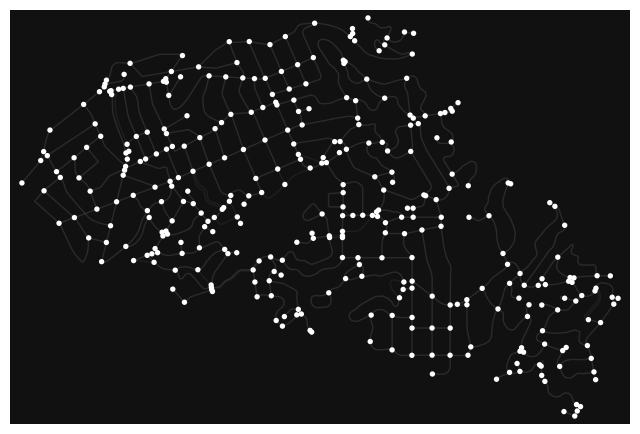

In [670]:
bla = [G2.get_edge_data(u,v,k)['capacity']/10 for u,v,k in G2.edges]
fig, ax = ox.plot.plot_graph(G2, edge_alpha=bla)

### Demande

In [671]:
def get_list(nodes, nodes_pos, nodes_neg, pos_val, neg_val, null_val):
    out=[null_val for k in range(len(nodes))]
    for k,node in enumerate(nodes):
        if node in nodes_neg:
            out[k]=neg_val
        elif node in nodes_pos:
            out[k]=pos_val
    return out

In [672]:
class Car:
    def __init__(self, departure_node, arrival_node):
        self.dep=departure_node
        self.old_loc=departure_node
        self.loc=departure_node
        self.arr=arrival_node
        self.completed=(departure_node==arrival_node)
    
    def update_loc(self, new_loc):
        self.old_loc=self.loc
        self.loc=new_loc
        self.completed=(self.loc==self.arr)
        return self
    
    def __repr__(self):
        return f'({self.dep}, {self.loc}, {self.arr}, {self.completed})'

In [681]:
class Car_fleet:
    def __init__(self, graph, size=2*50):
        self.graph:nx.MultiDiGraph = graph

        while True:
            trajs = self.get_trajs(size)
            # Check if every pair has a valid path
            if all(nx.has_path(graph, s, t) for s, t in trajs):
                break
            print("Regenerating trajectories: some nodes are disconnected.")

        self.trajs = trajs
        self.list = [Car(s, t) for s, t in self.trajs]
        self.cnt=0
        # print(f'{self.cnt} : {sum(self.get_completed())} \nBlocked: {sum(self.get_edge_blocked().values())} of {self.graph.number_of_edges()}')

    def get_trajs(self, size):
        nodes_list=list(self.graph.nodes)
        chosen=np.random.choice(self.graph.number_of_nodes(), size=size, replace=False)
        demand_pos = [nodes_list[k] for k in chosen[:size//2]]
        demand_neg = [nodes_list[k] for k in chosen[size//2:size]]
        return list(zip(demand_pos, demand_neg))

    def __repr__(self):
        return f'{self.list}'

    def get_loc(self):
        return [car.loc for car in self.list]
    def get_arr(self):
        return [car.arr for car in self.list]
    def get_completed(self):
        return [car.completed for car in self.list]
    def all_completed(self):
        return all(self.get_completed())

    def get_edge_blocked(self):
        return {(u,v):edge_data['weight']>2 for u,v,edge_data in list(self.graph.edges(data=True))}
    
    def handle_interactions(self, node1, node2, demand_delta, new_weight, op):
        self.graph[node1][node2][0]['demand']+=demand_delta
        if op(self.graph[node1][node2][0]['demand'], self.graph[node1][node2][0]['capacity']):
            self.graph[node1][node2][0]['weight']=new_weight

    def get_path_and_cost(self, node1, node2, weight):
        path = nx.shortest_path(self.graph, node1, node2, weight)
        cost = nx.path_weight(self.graph, path, weight)
        return path, cost

    def update_fleet(self, interactions=False):
        if not self.all_completed():
            paths, total_cost = [], []
            for car in self.list:
                if not car.completed:
                    if interactions and self.cnt>0:
                        self.handle_interactions(car.old_loc, car.loc, -1, 1, op=operator.lt) # Update old edges
                    path, cost = self.get_path_and_cost(car.loc, car.arr, weight='weight')
                    if interactions:
                        self.handle_interactions(car.loc, path[1], 1, 10000, op=operator.ge) # Update new edges
                else:
                    path, cost = [car.loc, car.loc], 0

                paths.append(path)
                total_cost.append(cost)

            length = max(map(len, paths))
            paths_array = np.array([xi + [xi[-1]] * (length - len(xi)) for xi in paths], dtype=object)
            self.list = [
                car.update_loc(loc) if not car.completed else car
                for car, loc in zip(self.list, paths_array[:, 1])
            ]
            self.cnt+=1
            # print(sum(total_cost))
            # print(f'{self.cnt} : {sum(self.get_completed())} \nBlocked: {sum(self.get_edge_blocked().values())} of {self.graph.number_of_edges()}')

    def display(self, ax, edge_alpha=None, edge_list=None):
        node_c = get_list(list(self.graph.nodes), self.get_loc(), self.get_arr(), 'r', 'g', 'grey')
        if edge_list:
            edge_c = ['orange' if edge_data['weight']>2 else 'grey' for u,v,edge_data in list(self.graph.edges(data=True))]
        ox.plot.plot_graph(
                self.graph,
                ax=ax,          # Use the animation's axis
                show=False,     # Don't open a new window now
                close=False,    # Don't close the plot
                node_color=node_c,
                edge_alpha=edge_alpha if edge_alpha else None,
                edge_color=edge_c if edge_c else None
            )

### Dynamique induite et update

On suppose qu'un chemin existe toujours -> pas forcément vrai suivant la modélisation

### Update demand

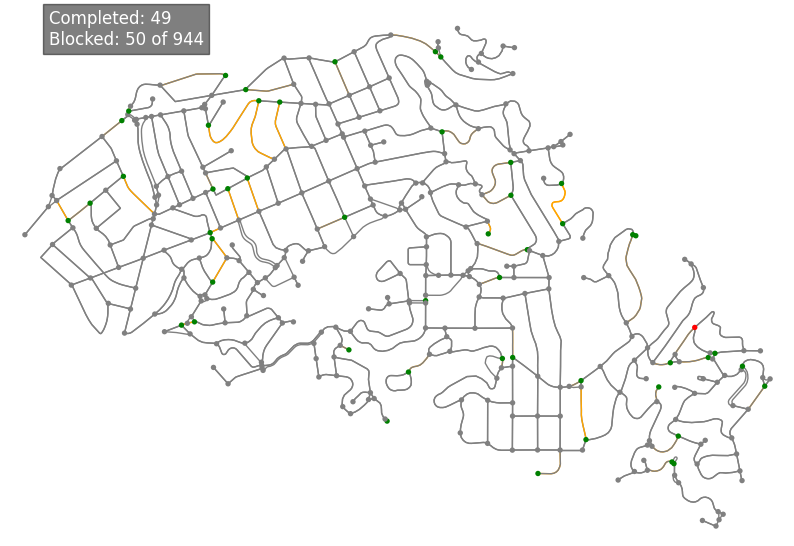

In [ ]:
demand=Car_fleet(G3.copy())

fig, ax = plt.subplots(figsize=(10, 8))

def update(frame):
    ax.clear()
    
    if frame > 0:
        demand.update_fleet(interactions=True)

    demand.display(ax=ax, edge_list=True)
    ax.text(0.05, 0.95, f'Completed: {sum(demand.get_completed())} \nBlocked: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}', 
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

ani = FuncAnimation(fig, update, frames=50, interval=150, repeat=False)

ani.save("ani.gif", writer='pillow')
plt.show()